### B1 Pipeline : Technical Indicators Only

In [1]:
import polars as pl
import numpy as np
import os, joblib, pickle
from datetime import date
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
import matplotlib.pyplot as plt

In [2]:
Model_path = "../../data/model_staging/tech_modeling_table.parquet"

df_model = pl.read_parquet(Model_path)
print(f"Shape: {df_model.shape}")
print(f"Target direction distribution:\n{df_model['target_class'].value_counts().sort('target_class')}")

Shape: (24048, 243)
Target direction distribution:
shape: (3, 2)
┌──────────────┬───────┐
│ target_class ┆ count │
│ ---          ┆ ---   │
│ i64          ┆ u32   │
╞══════════════╪═══════╡
│ 0            ┆ 7955  │
│ 1            ┆ 6428  │
│ 2            ┆ 9665  │
└──────────────┴───────┘


In [3]:
# ── Add year/quarter for expanding-window folds ──────────────
df_model = df_model.with_columns([
    pl.col("earnings_date").dt.year().alias("year"),
    pl.col("earnings_date").dt.quarter().alias("quarter"),
])
df_model = df_model.filter(pl.col("year") <= 2025)

INITIAL_TRAIN_YEARS = 7
EXCLUDE_COLS = [
    "symbol", "earnings_date", "entry_price", "target_return",
    "target_class", "max_high", "min_high", "max_day", "min_day",
    "year", "quarter",
    "target_return_close_t10",
    "target_class_close_t10",
    "target_return_avg_high",
    "target_class_avg_high",
    "car_3day",
    "car_t2_t10",
]
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]
print(f"Total features: {len(feature_cols)}")

unique_quarters = df_model.select(["year", "quarter"]).unique().sort(["year", "quarter"])
quarters_list = unique_quarters.to_dicts()

earliest_year = quarters_list[0]["year"]
initial_train_end_year = earliest_year + INITIAL_TRAIN_YEARS - 1
first_test_idx = next(i for i, q in enumerate(quarters_list) if q["year"] > initial_train_end_year)

print(f"Initial training: {earliest_year}–{initial_train_end_year} ({INITIAL_TRAIN_YEARS} yrs)")
print(f"First test: {quarters_list[first_test_idx]}")

folds_data = []
fold_num = 1

for test_quarter_idx in range(first_test_idx, len(quarters_list)):
    test_q = quarters_list[test_quarter_idx]
    val_q  = quarters_list[test_quarter_idx - 1]
    test_label = f"{test_q['year']}_Q{test_q['quarter']}"

    test_data = df_model.filter(
        (pl.col("year") == test_q["year"]) & (pl.col("quarter") == test_q["quarter"])
    )
    train_data = df_model.filter(
        (pl.col("year") < val_q["year"]) |
        ((pl.col("year") == val_q["year"]) & (pl.col("quarter") < val_q["quarter"]))
    )

    if len(train_data) == 0 or len(test_data) == 0:
        continue

    X_train = train_data.select(feature_cols).to_numpy()
    X_test  = test_data.select(feature_cols).to_numpy()

    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test),  np.nan, X_test)

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    folds_data.append({
        "fold_num":    fold_num,
        "test_quarter": test_label,
        "test_year":   test_q["year"],
        "X_train":     X_train,    "X_test":     X_test,
        "X_train_sc":  X_train_sc, "X_test_sc":  X_test_sc,
        "y_train_cls": train_data["target_class"].to_numpy(),
        "y_test_cls":  test_data["target_class"].to_numpy(),
        "y_train_ret": train_data["target_return"].to_numpy(),
        "y_test_ret":  test_data["target_return"].to_numpy(),
    })

    print(f"Fold {fold_num:2d} [{test_label}]:  "
          f"train={X_train.shape[0]:6,}  "
          f"test={X_test.shape[0]:4,}")

    fold_num += 1

print(f"\nTotal folds: {len(folds_data)}")

# For fold-across-year comparison charts
fold_years = [f["test_year"] for f in folds_data]


Total features: 228
Initial training: 2014–2020 (7 yrs)
First test: {'year': 2021, 'quarter': 1}
Fold  1 [2021_Q1]:  train=12,683  test= 492
Fold  2 [2021_Q2]:  train=13,169  test= 493
Fold  3 [2021_Q3]:  train=13,661  test= 493
Fold  4 [2021_Q4]:  train=14,154  test= 492
Fold  5 [2022_Q1]:  train=14,647  test= 494
Fold  6 [2022_Q2]:  train=15,139  test= 495
Fold  7 [2022_Q3]:  train=15,633  test= 493
Fold  8 [2022_Q4]:  train=16,128  test= 493
Fold  9 [2023_Q1]:  train=16,621  test= 492
Fold 10 [2023_Q2]:  train=17,114  test= 498
Fold 11 [2023_Q3]:  train=17,606  test= 496
Fold 12 [2023_Q4]:  train=18,104  test= 498
Fold 13 [2024_Q1]:  train=18,600  test= 496
Fold 14 [2024_Q2]:  train=19,098  test= 501
Fold 15 [2024_Q3]:  train=19,594  test= 499
Fold 16 [2024_Q4]:  train=20,095  test= 504
Fold 17 [2025_Q1]:  train=20,594  test= 502
Fold 18 [2025_Q2]:  train=21,098  test= 501
Fold 19 [2025_Q3]:  train=21,600  test= 502
Fold 20 [2025_Q4]:  train=22,101  test= 503

Total folds: 20


In [4]:
np.random.seed(42)

b0_clf = {"fold_acc": [], "preds": [], "true": []}
b0_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}

for f in folds_data:
    preds_cls = np.random.randint(0, 3, size=len(f["y_test_cls"]))
    acc = accuracy_score(f["y_test_cls"], preds_cls)
    b0_clf["fold_acc"].append(acc)
    b0_clf["preds"].extend(preds_cls)
    b0_clf["true"].extend(f["y_test_cls"])

    preds_ret = np.full(len(f["y_test_ret"]), f["y_train_ret"].mean())
    b0_reg["fold_mae"].append(mean_absolute_error(f["y_test_ret"], preds_ret))
    b0_reg["fold_rmse"].append(np.sqrt(mean_squared_error(f["y_test_ret"], preds_ret)))
    b0_reg["preds"].extend(preds_ret)
    b0_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']}: DA={acc:.4f}")

print(f"\nAvg DA:   {np.mean(b0_clf['fold_acc']):.4f}")
print(f"Avg MAE:  {np.mean(b0_reg['fold_mae']):.4f}")
print(f"Avg RMSE: {np.mean(b0_reg['fold_rmse']):.4f}")

Fold 1: DA=0.3780
Fold 2: DA=0.3509
Fold 3: DA=0.3651
Fold 4: DA=0.3374
Fold 5: DA=0.3644
Fold 6: DA=0.3192
Fold 7: DA=0.3185
Fold 8: DA=0.3570
Fold 9: DA=0.3638
Fold 10: DA=0.3454
Fold 11: DA=0.3327
Fold 12: DA=0.3494
Fold 13: DA=0.3710
Fold 14: DA=0.3693
Fold 15: DA=0.3327
Fold 16: DA=0.3413
Fold 17: DA=0.3745
Fold 18: DA=0.2974
Fold 19: DA=0.3088
Fold 20: DA=0.3777

Avg DA:   0.3477
Avg MAE:  0.0306
Avg RMSE: 0.0450


In [5]:
lr_clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")

for f in folds_data:
    lr_model.fit(f["X_train_sc"], f["y_train_cls"])
    preds = lr_model.predict(f["X_test_sc"])
    probs = lr_model.predict_proba(f["X_test_sc"])

    acc = accuracy_score(f["y_test_cls"], preds)
    lr_clf["fold_acc"].append(acc)
    lr_clf["preds"].extend(preds)
    lr_clf["probs"].extend(probs)
    lr_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: DA={acc:.4f}")

true = np.array(lr_clf["true"])
preds = np.array(lr_clf["preds"])
print(f"\nAvg DA:     {np.mean(lr_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"Precision:  {precision_score(true, preds, average='weighted'):.4f}")
print(f"Recall:     {recall_score(true, preds, average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(true, np.array(lr_clf['probs']), multi_class='ovr', average='weighted'):.4f}")

Fold 1 [2021_Q1]: DA=0.5305
Fold 2 [2021_Q2]: DA=0.3509
Fold 3 [2021_Q3]: DA=0.3712
Fold 4 [2021_Q4]: DA=0.4024
Fold 5 [2022_Q1]: DA=0.4757
Fold 6 [2022_Q2]: DA=0.3495
Fold 7 [2022_Q3]: DA=0.5030
Fold 8 [2022_Q4]: DA=0.6511
Fold 9 [2023_Q1]: DA=0.3963
Fold 10 [2023_Q2]: DA=0.3976
Fold 11 [2023_Q3]: DA=0.4153
Fold 12 [2023_Q4]: DA=0.4016
Fold 13 [2024_Q1]: DA=0.3730
Fold 14 [2024_Q2]: DA=0.3952
Fold 15 [2024_Q3]: DA=0.4168
Fold 16 [2024_Q4]: DA=0.3671
Fold 17 [2025_Q1]: DA=0.3765
Fold 18 [2025_Q2]: DA=0.5768
Fold 19 [2025_Q3]: DA=0.4024
Fold 20 [2025_Q4]: DA=0.4076

Avg DA:     0.4280
Pooled F1:  0.4248
Precision:  0.4231
Recall:     0.4279
Pooled AUC: 0.5943


In [6]:
linreg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
linreg_model = LinearRegression()

for f in folds_data:
    linreg_model.fit(f["X_train_sc"], f["y_train_ret"])
    preds = linreg_model.predict(f["X_test_sc"])

    mae = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    linreg["fold_mae"].append(mae)
    linreg["fold_rmse"].append(rmse)
    linreg["preds"].extend(preds)
    linreg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(linreg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(linreg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(linreg['true']), np.array(linreg['preds'])):.4f}")

Fold 1 [2021_Q1]: MAE=0.0357  RMSE=0.0502
Fold 2 [2021_Q2]: MAE=0.0264  RMSE=0.0371
Fold 3 [2021_Q3]: MAE=0.0241  RMSE=0.0333
Fold 4 [2021_Q4]: MAE=0.0254  RMSE=0.0379
Fold 5 [2022_Q1]: MAE=0.0376  RMSE=0.0534
Fold 6 [2022_Q2]: MAE=0.0488  RMSE=0.0584
Fold 7 [2022_Q3]: MAE=0.0275  RMSE=0.0353
Fold 8 [2022_Q4]: MAE=0.0386  RMSE=0.0553
Fold 9 [2023_Q1]: MAE=0.0274  RMSE=0.0357
Fold 10 [2023_Q2]: MAE=0.0259  RMSE=0.0379
Fold 11 [2023_Q3]: MAE=0.0221  RMSE=0.0338
Fold 12 [2023_Q4]: MAE=0.0315  RMSE=0.0422
Fold 13 [2024_Q1]: MAE=0.0273  RMSE=0.0423
Fold 14 [2024_Q2]: MAE=0.0271  RMSE=0.0420
Fold 15 [2024_Q3]: MAE=0.0304  RMSE=0.0617
Fold 16 [2024_Q4]: MAE=0.0334  RMSE=0.0576
Fold 17 [2025_Q1]: MAE=0.0273  RMSE=0.0373
Fold 18 [2025_Q2]: MAE=0.0371  RMSE=0.0573
Fold 19 [2025_Q3]: MAE=0.0255  RMSE=0.0377
Fold 20 [2025_Q4]: MAE=0.0279  RMSE=0.0386

Avg MAE:   0.0304
Avg RMSE:  0.0442
Pooled R²: 0.0226


In [7]:
rf_clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}
rf_clf_model = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)

for f in folds_data:
    rf_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = rf_clf_model.predict(f["X_test"])
    probs = rf_clf_model.predict_proba(f["X_test"])

    acc = accuracy_score(f["y_test_cls"], preds)
    rf_clf["fold_acc"].append(acc)
    rf_clf["preds"].extend(preds)
    rf_clf["probs"].extend(probs)
    rf_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: DA={acc:.4f}")

true = np.array(rf_clf["true"])
preds = np.array(rf_clf["preds"])
print(f"\nAvg DA:     {np.mean(rf_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"Precision:  {precision_score(true, preds, average='weighted'):.4f}")
print(f"Recall:     {recall_score(true, preds, average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(true, np.array(rf_clf['probs']), multi_class='ovr', average='weighted'):.4f}")

Fold 1 [2021_Q1]: DA=0.5610
Fold 2 [2021_Q2]: DA=0.4584
Fold 3 [2021_Q3]: DA=0.4118
Fold 4 [2021_Q4]: DA=0.4350
Fold 5 [2022_Q1]: DA=0.4798
Fold 6 [2022_Q2]: DA=0.3475
Fold 7 [2022_Q3]: DA=0.5558
Fold 8 [2022_Q4]: DA=0.6876
Fold 9 [2023_Q1]: DA=0.3455
Fold 10 [2023_Q2]: DA=0.3695
Fold 11 [2023_Q3]: DA=0.4254
Fold 12 [2023_Q4]: DA=0.5221
Fold 13 [2024_Q1]: DA=0.3548
Fold 14 [2024_Q2]: DA=0.4192
Fold 15 [2024_Q3]: DA=0.3988
Fold 16 [2024_Q4]: DA=0.3988
Fold 17 [2025_Q1]: DA=0.3586
Fold 18 [2025_Q2]: DA=0.6427
Fold 19 [2025_Q3]: DA=0.4183
Fold 20 [2025_Q4]: DA=0.4076

Avg DA:     0.4499
Pooled F1:  0.4167
Precision:  0.4208
Recall:     0.4497
Pooled AUC: 0.5975


In [8]:
rf_reg = {"fold_mae": [], "fold_rmse": [], "fold_r2": [], "preds": [], "true": []}
rf_reg_model = XGBRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)

for f in folds_data:
    rf_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = rf_reg_model.predict(f["X_test"])

    mae = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    r2 = r2_score(f["y_test_ret"], preds)
    rf_reg["fold_mae"].append(mae)
    rf_reg["fold_rmse"].append(rmse)
    rf_reg["fold_r2"].append(r2)
    rf_reg["preds"].extend(preds)
    rf_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

print(f"\nAvg MAE:   {np.mean(rf_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(rf_reg['fold_rmse']):.4f}")
print(f"Avg R²:    {np.mean(rf_reg['fold_r2']):.4f}")
print(f"Pooled R²: {r2_score(np.array(rf_reg['true']), np.array(rf_reg['preds'])):.4f}")

Fold 1 [2021_Q1]: MAE=0.0379  RMSE=0.0507  R²=0.0762
Fold 2 [2021_Q2]: MAE=0.0266  RMSE=0.0386  R²=-0.1192
Fold 3 [2021_Q3]: MAE=0.0249  RMSE=0.0343  R²=-0.0101
Fold 4 [2021_Q4]: MAE=0.0258  RMSE=0.0383  R²=0.0195
Fold 5 [2022_Q1]: MAE=0.0368  RMSE=0.0535  R²=-0.0030
Fold 6 [2022_Q2]: MAE=0.0483  RMSE=0.0615  R²=-1.0727
Fold 7 [2022_Q3]: MAE=0.0299  RMSE=0.0393  R²=-0.0973
Fold 8 [2022_Q4]: MAE=0.0407  RMSE=0.0561  R²=0.0331
Fold 9 [2023_Q1]: MAE=0.0278  RMSE=0.0370  R²=-0.0317
Fold 10 [2023_Q2]: MAE=0.0273  RMSE=0.0411  R²=0.0534
Fold 11 [2023_Q3]: MAE=0.0205  RMSE=0.0299  R²=0.0283
Fold 12 [2023_Q4]: MAE=0.0321  RMSE=0.0423  R²=-0.0528
Fold 13 [2024_Q1]: MAE=0.0273  RMSE=0.0408  R²=0.2257
Fold 14 [2024_Q2]: MAE=0.0272  RMSE=0.0417  R²=0.0803
Fold 15 [2024_Q3]: MAE=0.0281  RMSE=0.0374  R²=0.1337
Fold 16 [2024_Q4]: MAE=0.0330  RMSE=0.0588  R²=0.0732
Fold 17 [2025_Q1]: MAE=0.0287  RMSE=0.0398  R²=-0.3175
Fold 18 [2025_Q2]: MAE=0.0357  RMSE=0.0546  R²=0.1797
Fold 19 [2025_Q3]: MAE=0.0256

In [9]:
xgb_clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}
xgb_clf_model = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)

for f in folds_data:
    xgb_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = xgb_clf_model.predict(f["X_test"])
    probs = xgb_clf_model.predict_proba(f["X_test"])

    acc = accuracy_score(f["y_test_cls"], preds)
    xgb_clf["fold_acc"].append(acc)
    xgb_clf["preds"].extend(preds)
    xgb_clf["probs"].extend(probs)
    xgb_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: DA={acc:.4f}")

true = np.array(xgb_clf["true"])
preds = np.array(xgb_clf["preds"])
print(f"\nAvg DA:     {np.mean(xgb_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"Precision:  {precision_score(true, preds, average='weighted'):.4f}")
print(f"Recall:     {recall_score(true, preds, average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(true, np.array(xgb_clf['probs']), multi_class='ovr', average='weighted'):.4f}")

Fold 1 [2021_Q1]: DA=0.5244
Fold 2 [2021_Q2]: DA=0.4118
Fold 3 [2021_Q3]: DA=0.3631
Fold 4 [2021_Q4]: DA=0.4228
Fold 5 [2022_Q1]: DA=0.4757
Fold 6 [2022_Q2]: DA=0.3596
Fold 7 [2022_Q3]: DA=0.4929
Fold 8 [2022_Q4]: DA=0.5822
Fold 9 [2023_Q1]: DA=0.3862
Fold 10 [2023_Q2]: DA=0.3614
Fold 11 [2023_Q3]: DA=0.4113
Fold 12 [2023_Q4]: DA=0.4598
Fold 13 [2024_Q1]: DA=0.4032
Fold 14 [2024_Q2]: DA=0.3952
Fold 15 [2024_Q3]: DA=0.4269
Fold 16 [2024_Q4]: DA=0.3730
Fold 17 [2025_Q1]: DA=0.3267
Fold 18 [2025_Q2]: DA=0.6068
Fold 19 [2025_Q3]: DA=0.4203
Fold 20 [2025_Q4]: DA=0.4036

Avg DA:     0.4303
Pooled F1:  0.4023
Precision:  0.3994
Recall:     0.4302
Pooled AUC: 0.5679


In [10]:
xgb_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
xgb_reg_model = XGBRegressor(n_estimators=200, random_state=42)

for f in folds_data:
    xgb_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = xgb_reg_model.predict(f["X_test"])

    mae = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    xgb_reg["fold_mae"].append(mae)
    xgb_reg["fold_rmse"].append(rmse)
    xgb_reg["preds"].extend(preds)
    xgb_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(xgb_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(xgb_reg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(xgb_reg['true']), np.array(xgb_reg['preds'])):.4f}")

Fold 1 [2021_Q1]: MAE=0.0385  RMSE=0.0513
Fold 2 [2021_Q2]: MAE=0.0274  RMSE=0.0399
Fold 3 [2021_Q3]: MAE=0.0263  RMSE=0.0357
Fold 4 [2021_Q4]: MAE=0.0267  RMSE=0.0386
Fold 5 [2022_Q1]: MAE=0.0372  RMSE=0.0544
Fold 6 [2022_Q2]: MAE=0.0492  RMSE=0.0636
Fold 7 [2022_Q3]: MAE=0.0312  RMSE=0.0409
Fold 8 [2022_Q4]: MAE=0.0418  RMSE=0.0571
Fold 9 [2023_Q1]: MAE=0.0280  RMSE=0.0380
Fold 10 [2023_Q2]: MAE=0.0278  RMSE=0.0414
Fold 11 [2023_Q3]: MAE=0.0215  RMSE=0.0304
Fold 12 [2023_Q4]: MAE=0.0330  RMSE=0.0435
Fold 13 [2024_Q1]: MAE=0.0281  RMSE=0.0414
Fold 14 [2024_Q2]: MAE=0.0279  RMSE=0.0421
Fold 15 [2024_Q3]: MAE=0.0292  RMSE=0.0386
Fold 16 [2024_Q4]: MAE=0.0342  RMSE=0.0600
Fold 17 [2025_Q1]: MAE=0.0297  RMSE=0.0416
Fold 18 [2025_Q2]: MAE=0.0363  RMSE=0.0545
Fold 19 [2025_Q3]: MAE=0.0270  RMSE=0.0401
Fold 20 [2025_Q4]: MAE=0.0299  RMSE=0.0420

Avg MAE:   0.0315
Avg RMSE:  0.0448
Pooled R²: 0.0073


In [11]:
print("=== Classification (3-Class: <2% / 2-4% / ≥4%) ===")
print(f"{'Model':<25} {'Avg DA%':>10} {'Pooled F1':>10} {'Precision':>10} {'Recall':>10} {'AUC':>8}")
print("-" * 75)

for name, r in [("B0 Random", b0_clf), ("Logistic Regression", lr_clf),
                ("Random Forest", rf_clf), ("XGBoost", xgb_clf)]:
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    avg_acc = np.mean(r["fold_acc"])
    f1 = f1_score(true, preds, average="weighted")
    prec = precision_score(true, preds, average="weighted")
    rec = recall_score(true, preds, average="weighted")
    if r.get("probs"):
        auc = roc_auc_score(true, np.array(r["probs"]), multi_class='ovr', average='weighted')
        auc_str = f"{auc:>8.4f}"
    else:
        auc_str = f"{'—':>8}"
    print(f"{name:<25} {avg_acc:>10.4f} {f1:>10.4f} {prec:>10.4f} {rec:>10.4f} {auc_str}")

print(f"\n=== Regression (Peak Return) ===")
print(f"{'Model':<25} {'Avg MAE':>10} {'Avg RMSE':>10} {'Pooled R²':>10}")
print("-" * 60)

for name, r in [("B0 Mean", b0_reg), ("Linear Regression", linreg),
                ("Random Forest", rf_reg), ("XGBoost", xgb_reg)]:
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    print(f"{name:<25} {np.mean(r['fold_mae']):>10.4f} {np.mean(r['fold_rmse']):>10.4f} {r2_score(true, preds):>10.4f}")

=== Classification (3-Class: <2% / 2-4% / ≥4%) ===
Model                        Avg DA%  Pooled F1  Precision     Recall      AUC
---------------------------------------------------------------------------
B0 Random                     0.3477     0.3524     0.3694     0.3477        —
Logistic Regression           0.4280     0.4248     0.4231     0.4279   0.5943
Random Forest                 0.4499     0.4167     0.4208     0.4497   0.5975
XGBoost                       0.4303     0.4023     0.3994     0.4302   0.5679

=== Regression (Peak Return) ===
Model                        Avg MAE   Avg RMSE  Pooled R²
------------------------------------------------------------
B0 Mean                       0.0306     0.0450    -0.0189
Linear Regression             0.0304     0.0442     0.0226
Random Forest                 0.0307     0.0437     0.0507
XGBoost                       0.0315     0.0448     0.0073


In [12]:
plt.rcParams['figure.facecolor'] = 'white'     # Figure background
plt.rcParams['axes.facecolor'] = 'white'       # Plot area background
plt.rcParams['text.color'] = 'black'           # General text color (title, legend)
plt.rcParams['axes.labelcolor'] = 'black'      # X and Y axis label color
plt.rcParams['xtick.color'] = 'black'          # X-axis tick mark color
plt.rcParams['ytick.color'] = 'black'          # Y-axis tick mark color
plt.rcParams['axes.edgecolor'] = 'black'       # Color of the box around the plot area (spines)
plt.rcParams['grid.color'] = 'gray'            # Optional: for grid lines on white

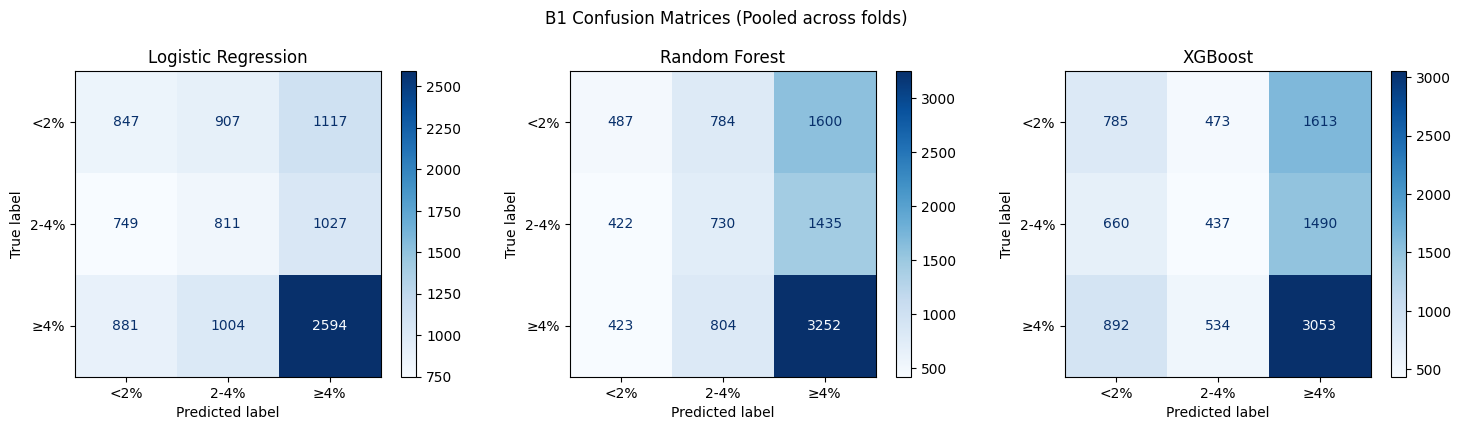

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Logistic Regression", lr_clf),
                                 ("Random Forest", rf_clf),
                                 ("XGBoost", xgb_clf)]):
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    ConfusionMatrixDisplay.from_predictions(true, preds, ax=ax, cmap="Blues",
                                            display_labels=["<2%", "2-4%", "≥4%"])
    ax.set_title(name)

plt.suptitle("B1 Confusion Matrices (Pooled across folds)", y=1.02)
plt.tight_layout()
plt.show()

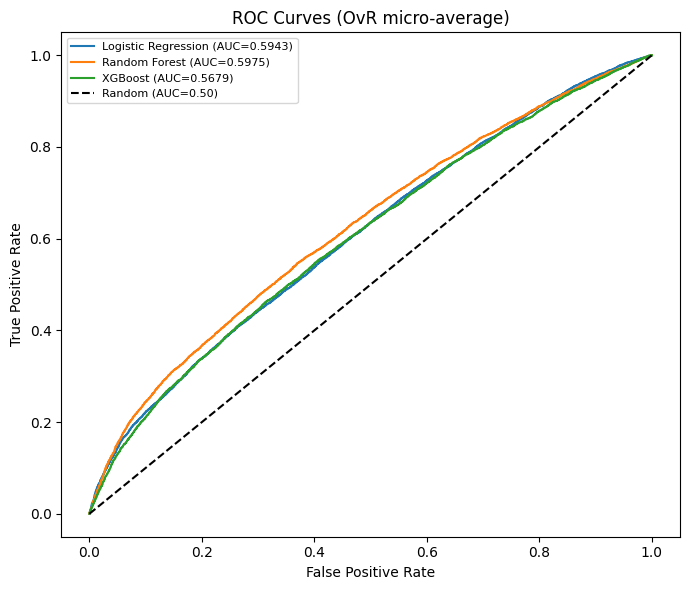

In [14]:
# 3-class ROC: use roc_auc_score with OvR
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

classes = [0, 1, 2]
labels = ["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]
fig, ax = plt.subplots(figsize=(7, 6))

for name, r in [("Logistic Regression", lr_clf),
                ("Random Forest", rf_clf),
                ("XGBoost", xgb_clf)]:
    y_true_bin = label_binarize(np.array(r["true"]), classes=classes)
    y_score = np.array(r["probs"])
    auc_val = roc_auc_score(np.array(r["true"]), y_score, multi_class='ovr', average='weighted')

    # Plot the OvR micro-average ROC
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (OvR micro-average)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


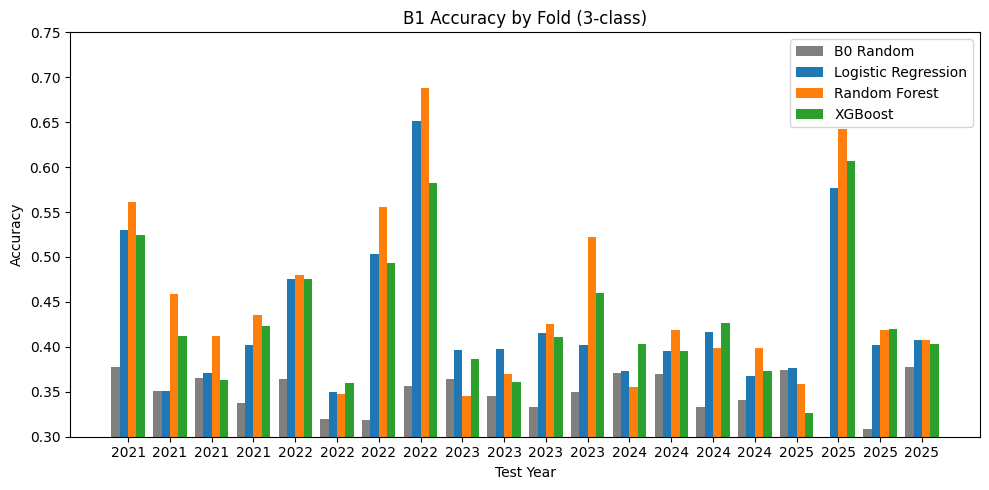

In [15]:
fold_years = [f["test_year"] for f in folds_data]
x = np.arange(len(fold_years))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, b0_clf["fold_acc"], width, label="B0 Random", color="gray")
ax.bar(x, lr_clf["fold_acc"], width, label="Logistic Regression")
ax.bar(x + width, rf_clf["fold_acc"], width, label="Random Forest")
ax.bar(x + 2*width, xgb_clf["fold_acc"], width, label="XGBoost")

ax.set_xticks(x + width/2)
ax.set_xticklabels(fold_years)
ax.set_xlabel("Test Year")
ax.set_ylabel("Accuracy")
ax.set_title("B1 Accuracy by Fold (3-class)")
ax.legend()
ax.set_ylim(0.3, 0.75)
plt.tight_layout()
plt.show()

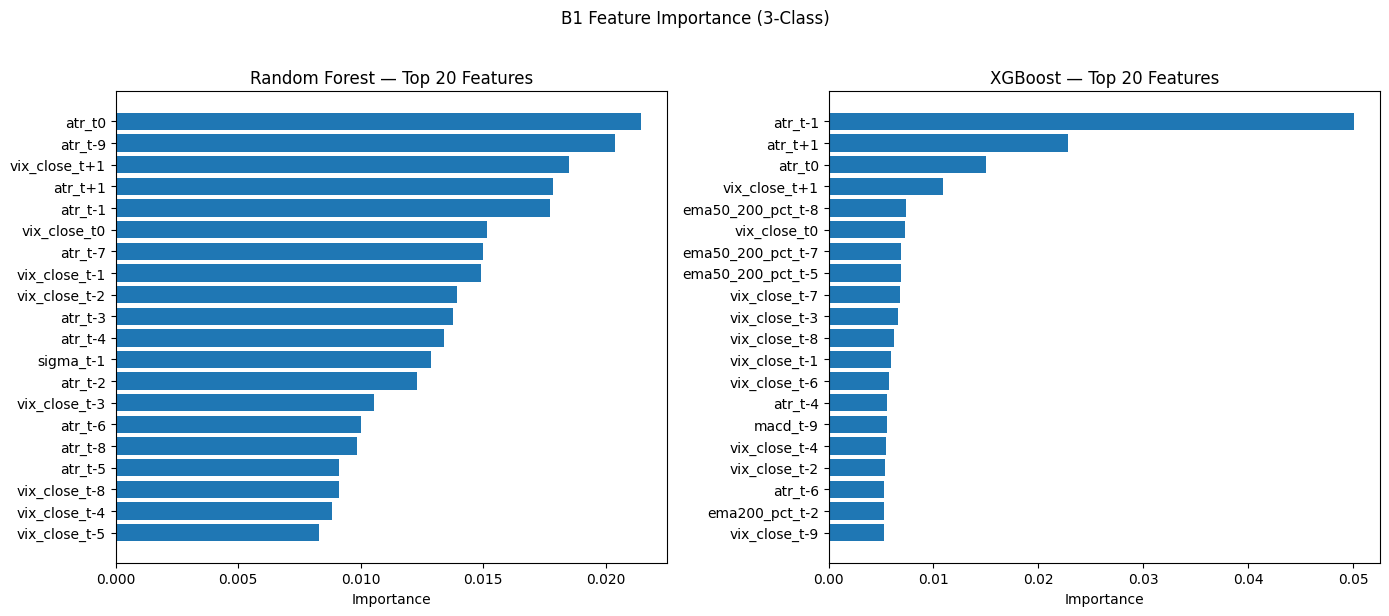

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
rf_imp = rf_clf_model.feature_importances_
rf_top_idx = np.argsort(rf_imp)[-20:]
axes[0].barh(np.array(feature_cols)[rf_top_idx], rf_imp[rf_top_idx])
axes[0].set_title("Random Forest — Top 20 Features")
axes[0].set_xlabel("Importance")

# XGBoost
xgb_imp = xgb_clf_model.feature_importances_
xgb_top_idx = np.argsort(xgb_imp)[-20:]
axes[1].barh(np.array(feature_cols)[xgb_top_idx], xgb_imp[xgb_top_idx])
axes[1].set_title("XGBoost — Top 20 Features")
axes[1].set_xlabel("Importance")

plt.suptitle("B1 Feature Importance (3-Class)", y=1.02)
plt.tight_layout()
plt.show()

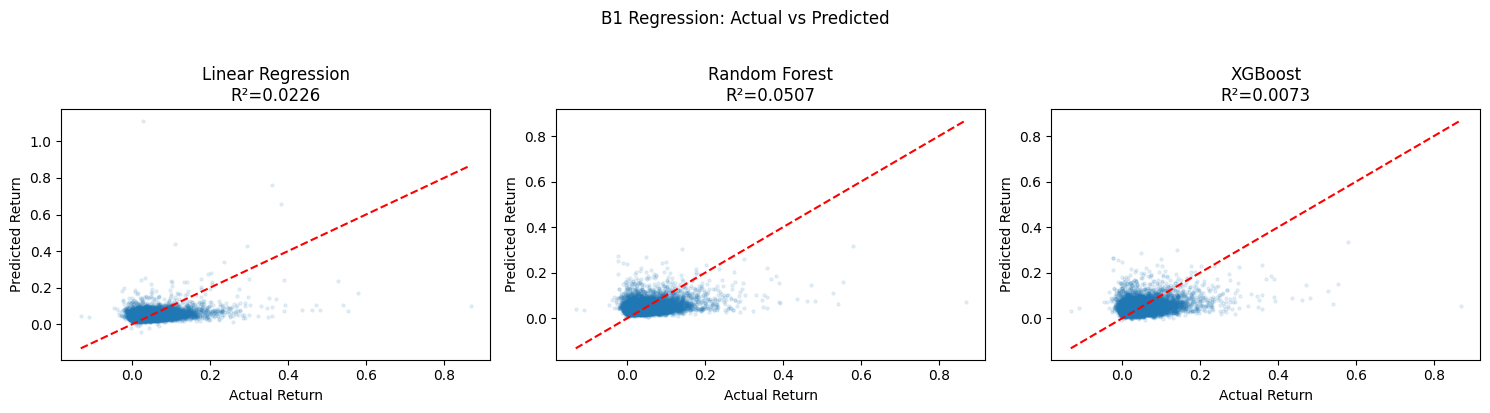

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Linear Regression", linreg),
                                  ("Random Forest", rf_reg),
                                  ("XGBoost", xgb_reg)]):
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    ax.scatter(true, preds, alpha=0.1, s=5)
    ax.plot([true.min(), true.max()], [true.min(), true.max()], "r--")
    ax.set_xlabel("Actual Return")
    ax.set_ylabel("Predicted Return")
    ax.set_title(f"{name}\nR²={r2_score(true, preds):.4f}")

plt.suptitle("B1 Regression: Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

In [20]:
os.makedirs("models", exist_ok=True)

for name, model in [("lr_clf", lr_model), ("linreg", linreg_model),
                     ("rf_clf", rf_clf_model), ("rf_reg", rf_reg_model),
                     ("xgb_clf", xgb_clf_model), ("xgb_reg", xgb_reg_model)]:
    joblib.dump(model, f"models/b1_{name}.pkl")
    print(f"Saved models/b1_{name}.pkl")

with open("models/b1_results.pkl", "wb") as f:
    pickle.dump({
        "clf": {"B0 Random": b0_clf, "Logistic Regression": lr_clf,
                "Random Forest": rf_clf, "XGBoost": xgb_clf},
        "reg": {"B0 Mean": b0_reg, "Linear Regression": linreg,
                "Random Forest": rf_reg, "XGBoost": xgb_reg},
    }, f)
print("Saved models/b1_results.pkl")

Saved models/b1_lr_clf.pkl
Saved models/b1_linreg.pkl
Saved models/b1_rf_clf.pkl
Saved models/b1_rf_reg.pkl
Saved models/b1_xgb_clf.pkl
Saved models/b1_xgb_reg.pkl
Saved models/b1_results.pkl
